# Introduction

Let's create a simple MLP structure.

# Prepare the data

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

# Generate nonlinear data
X = torch.linspace(-2, 2, 200).unsqueeze(1)
y = torch.sin(X) + 0.1 * torch.randn_like(X)

# Define a NLP

In [2]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()

# Train

In [3]:
# Define loss
criterion = nn.MSELoss()
# Initialize the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train sequence
for epoch in range(2000):
    optimizer.zero_grad()
    # predictions
    preds = model(X)
    # calculate loss
    loss = criterion(preds, y)
    # backpropagation
    loss.backward()
    optimizer.step()

# Visualize

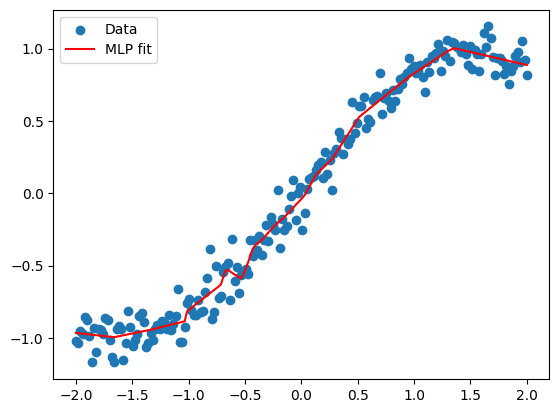

In [4]:
with torch.no_grad():
    y_pred = model(X)

plt.scatter(X.numpy(), y.numpy(), label="Data")
plt.plot(X.numpy(), y_pred.numpy(), color="red", label="MLP fit")
plt.legend()
plt.show()